# 02C: Sentiment-Enhanced K-Means + Regression

## Objective
Integrate news sentiment (FinBERT) into both clustering and stock price regression.

## What This Notebook Adds
1. Shared raw news loading from `news_data/data/news_headlines_raw.csv`
2. Feature conversion: compute daily per-stock `sentiment_score` with FinBERT
3. K-Means optimization: include sentiment features in stock-level clustering
4. Regression optimization: include sentiment features for next-day price prediction

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost kagglehub yfinance transformers torch requests

import os
import time
import requests
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor

import yfinance as yf
from transformers import pipeline
import kagglehub

sns.set_palette('husl')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print('[OK] Libraries loaded')

Note: you may need to restart the kernel to use updated packages.
[OK] Libraries loaded


In [2]:
# Resolve paths
cwd = Path.cwd()
REG_TASK = '02_stock_price_regression'
CLUSTER_TASK = '03_stock_clustering_analysis'

if cwd.name == 'implementation':
    reg_root = cwd.parent
elif cwd.name == REG_TASK:
    reg_root = cwd
elif (cwd / REG_TASK).exists():
    reg_root = cwd / REG_TASK
else:
    reg_root = cwd

workspace_root = reg_root.parent
cluster_root = workspace_root / CLUSTER_TASK
cluster_data_dir = cluster_root / 'data'

GRAPH_DIR = reg_root / 'graph'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = reg_root / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

raw_cache = cluster_data_dir / 'sp500_raw.csv'
cluster_assign_path = cluster_data_dir / '03A_stock_cluster_assignments.csv'
cluster_summary_path = cluster_data_dir / '03A_cluster_feature_summary.csv'

print(f'Regression root: {reg_root}')
print(f'Cluster data dir: {cluster_data_dir}')

Regression root: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\02_stock_price_regression
Cluster data dir: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\data


In [3]:
# Load base market data and 03A cluster outputs
if raw_cache.exists():
    data = pd.read_csv(raw_cache)
    print('[CACHE] Loaded shared raw cache')
else:
    path = kagglehub.dataset_download('camnugent/sandp500')
    csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
    data = pd.read_csv(os.path.join(path, csv_file))

if not cluster_assign_path.exists() or not cluster_summary_path.exists():
    raise FileNotFoundError('Please run 03A_KMeans_Clustering.ipynb first to generate required files.')

cluster_assign = pd.read_csv(cluster_assign_path)
cluster_summary = pd.read_csv(cluster_summary_path)

# Use all stocks from largest 3 clusters as fallback universe.
cluster_stock_map = cluster_assign[['Name', 'cluster']].drop_duplicates()
cluster_size = cluster_stock_map.groupby('cluster')['Name'].nunique().sort_values(ascending=False)
top_clusters = cluster_size.head(3).index.astype(int).tolist()
top_clusters_sorted = sorted(top_clusters)

available_symbols = set(data['Name'].unique())
cluster_selected = sorted(
    s for s in cluster_stock_map[cluster_stock_map['cluster'].isin(top_clusters)]['Name'].unique()
    if s in available_symbols
)

# Force 5-stock modeling set requested by user.
requested_stocks = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
selected = [s for s in requested_stocks if s in available_symbols]

if len(selected) < len(requested_stocks):
    missing_requested = [s for s in requested_stocks if s not in available_symbols]
    print(f'[WARN] Missing requested symbols in dataset: {missing_requested}')

# If none of the requested symbols exist, fall back to cluster-based selection.
if not selected:
    selected = cluster_selected

if not selected:
    raise ValueError('No overlapping symbols found between market data and selected universe.')

data = data[data['Name'].isin(selected)].copy()
data['date'] = pd.to_datetime(data['date'])

print(f'Selected clusters (fallback): {', '.join(map(str, top_clusters_sorted))}')
print(f'Selected stocks for 02C: {selected}')
print(f'Market rows: {len(data)}')

[CACHE] Loaded shared raw cache
Selected clusters (fallback): 0, 1, 4
Selected stocks for 02C: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
Market rows: 6011


## Step 1: Shared News Data Loading (news_data)

Notes:
- Shared raw news is created once by `project_folder/news_data/implementation/01_News_Data_Ingestion.ipynb`.
- 02C only reads the canonical CSV and does not fetch news locally.
- Synthetic proxy headlines are intentionally excluded from the shared raw layer.

In [ ]:
# Shared news cache controls
NEWS_DATA_ROOT = workspace_root / 'news_data'
NEWS_RAW_PATH = NEWS_DATA_ROOT / 'data' / 'news_headlines_raw.csv'

symbols_for_news = selected
print(f'Shared news path: {NEWS_RAW_PATH}')
print(f'Symbols for news load: {symbols_for_news}')

if not NEWS_RAW_PATH.exists():
    raise FileNotFoundError(
        f'Missing shared raw news file: {NEWS_RAW_PATH}\n'
        'Run project_folder/news_data/implementation/01_News_Data_Ingestion.ipynb first to fetch once for all tasks.'
    )

print(f'[NEWS] Loading from shared canonical CSV: {NEWS_RAW_PATH}')
news_df = pd.read_csv(NEWS_RAW_PATH)

required_cols = {'Name', 'date', 'headline'}
missing_cols = required_cols - set(news_df.columns)
if missing_cols:
    raise ValueError(f'Shared raw news file is missing required columns: {sorted(missing_cols)}')

news_df['Name'] = news_df['Name'].astype(str).str.strip()
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce').dt.normalize()
news_df['headline'] = news_df['headline'].astype(str).str.strip()

if 'source' not in news_df.columns:
    news_df['source'] = 'unknown'
if 'url' not in news_df.columns:
    news_df['url'] = ''
if 'published_at' not in news_df.columns:
    news_df['published_at'] = ''
news_df['source'] = news_df['source'].astype(str).str.strip().str.lower()

data_start = pd.to_datetime(data['date']).min().normalize()
data_end = pd.to_datetime(data['date']).max().normalize()

news_df = news_df.dropna(subset=['Name', 'date', 'headline']).copy()
news_df = news_df[news_df['Name'].isin(symbols_for_news)].copy()
news_df = news_df[(news_df['date'] >= data_start - pd.Timedelta(days=30)) & (news_df['date'] <= data_end)].copy()
news_df = news_df[news_df['source'] != 'price_proxy_fallback'].copy()
news_df = news_df.drop_duplicates(subset=['Name', 'date', 'headline', 'source', 'url']).reset_index(drop=True)

print(f'[SHARED] Loaded raw news rows: {len(news_df)}')
print(f'[SHARED] Coverage: {news_df["date"].min()} -> {news_df["date"].max()}')
print('[SHARED] Source counts:')
print(news_df['source'].value_counts(dropna=False).head(10))
print(news_df[['Name', 'date', 'source']].head())

Shared news path: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\news_data\data\news_headlines_raw.csv
Symbols for news load: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
[NEWS] Loading from: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\02_stock_price_regression\data\02C_news_headlines_cache.csv
[SHARED] Loaded raw news rows: 0
[SHARED] Coverage: NaT -> NaT
[SHARED] Source counts:
Series([], Name: count, dtype: int64)
Empty DataFrame
Columns: [Name, date, source]
Index: []


## Step 2: FinBERT Sentiment Scoring

Generate daily per-stock `sentiment_score` using `ProsusAI/finbert`.

In [5]:
if len(news_df) == 0:
    sentiment_daily = pd.DataFrame(columns=['Name', 'date', 'sentiment_score', 'headline_count'])
else:
    sentiment_pipe = pipeline('sentiment-analysis', model='ProsusAI/finbert', truncation=True)

    def label_to_score(label):
        m = str(label).lower()
        if 'positive' in m:
            return 1.0
        if 'negative' in m:
            return -1.0
        return 0.0

    batch_size = 32
    scores = []
    texts = news_df['headline'].astype(str).tolist()

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        preds = sentiment_pipe(batch)
        scores.extend([label_to_score(p.get('label', 'neutral')) for p in preds])

    news_df['sentiment_raw'] = scores

    sentiment_daily = (
        news_df.groupby(['Name', 'date'])['sentiment_raw']
        .agg(['mean', 'count'])
        .reset_index()
        .rename(columns={'mean': 'sentiment_score', 'count': 'headline_count'})
    )

sentiment_path = DATA_DIR / '02C_daily_sentiment_scores.csv'
sentiment_daily.to_csv(sentiment_path, index=False)
print(f'[OK] Saved: {sentiment_path.name}')
print(f'Sentiment daily rows: {len(sentiment_daily)}')

[OK] Saved: 02C_daily_sentiment_scores.csv
Sentiment daily rows: 0


## Step 3: Feature Engineering + Sentiment Merge

Merge sentiment into price features and create sentiment lag/rolling features.

In [14]:
data = data.sort_values(['Name', 'date']).reset_index(drop=True)

def create_features(stock_df):
    stock_df = stock_df.sort_values('date').reset_index(drop=True).copy()

    stock_df['target'] = stock_df['close'].shift(-1)
    # Predict return instead of absolute price to improve cross-stock stability.
    stock_df['target_return'] = (stock_df['target'] - stock_df['close']) / stock_df['close']

    stock_df['price_range'] = (stock_df['high'] - stock_df['low']) / stock_df['open']
    stock_df['close_open_diff'] = (stock_df['close'] - stock_df['open']) / stock_df['open']
    stock_df['high_low_ratio'] = stock_df['high'] / stock_df['low']
    stock_df['daily_return'] = stock_df['close'].pct_change()
    stock_df['lag_return_1'] = stock_df['daily_return'].shift(1)
    stock_df['lag_return_5'] = stock_df['close'].pct_change(5)
    stock_df['volume_norm'] = stock_df['volume'] / stock_df['volume'].rolling(20).mean()
    stock_df['volume_trend'] = (stock_df['volume'] - stock_df['volume'].rolling(20).mean()) / stock_df['volume'].rolling(20).mean()
    stock_df['close_ma5'] = stock_df['close'].rolling(5).mean()
    stock_df['close_ma20'] = stock_df['close'].rolling(20).mean()
    stock_df['close_ma50'] = stock_df['close'].rolling(50).mean()
    stock_df['momentum_5'] = (stock_df['close'] - stock_df['close'].shift(5)) / stock_df['close'].shift(5)
    stock_df['momentum_20'] = (stock_df['close'] - stock_df['close'].shift(20)) / stock_df['close'].shift(20)
    stock_df['volatility_20'] = stock_df['daily_return'].rolling(20).std()
    stock_df['volatility_60'] = stock_df['daily_return'].rolling(60).std()

    delta = stock_df['daily_return'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    stock_df['rsi'] = 100 - (100 / (1 + rs))

    return stock_df

reg_df = pd.concat([create_features(data[data['Name'] == s]) for s in selected], ignore_index=True)
reg_df = reg_df.dropna().reset_index(drop=True)

cluster_map = cluster_assign[['Name', 'cluster']].drop_duplicates('Name')
reg_df = reg_df.merge(cluster_map, on='Name', how='left')
reg_df['cluster'] = reg_df['cluster'].astype(int)

sentiment_daily['date'] = pd.to_datetime(sentiment_daily['date'], errors='coerce').dt.normalize() if len(sentiment_daily) else pd.to_datetime([])
reg_df['date'] = pd.to_datetime(reg_df['date']).dt.normalize()

reg_df = reg_df.merge(sentiment_daily[['Name', 'date', 'sentiment_score', 'headline_count']], on=['Name', 'date'], how='left')
reg_df['sentiment_score'] = reg_df['sentiment_score'].fillna(0.0)
reg_df['headline_count'] = reg_df['headline_count'].fillna(0.0)

reg_df = reg_df.sort_values(['Name', 'date']).reset_index(drop=True)

# Strict no-leakage lagging features:
# For prediction date t, use only t-1 ... t-10 sentiment, never current/future sentiment.
def add_sentiment_lag_decay_features(df, lookback_days=10, decay_rate=0.25):
    out = []
    base_weights = np.exp(-decay_rate * np.arange(lookback_days))  # lag1 weight > lag10 weight

    for name, g in df.groupby('Name', sort=False):
        g = g.sort_values('date').copy()

        s = g['sentiment_score'].astype(float)
        h = g['headline_count'].astype(float)

        # Pure lagging features (no leading leakage)
        g['sentiment_lag1'] = s.shift(1)
        g['sentiment_lag2'] = s.shift(2)
        g['sentiment_lag3'] = s.shift(3)

        # Rolling lag means built from previous days only
        g['sentiment_lag3_mean'] = s.shift(1).rolling(3, min_periods=1).mean()
        g['sentiment_lag5_mean'] = s.shift(1).rolling(min(5, lookback_days), min_periods=1).mean()

        # Weighted decay over lag1..lag10 (recency gets larger weight)
        lag_sent = np.column_stack([s.shift(i).values for i in range(1, lookback_days + 1)])
        lag_head = np.column_stack([h.shift(i).values for i in range(1, lookback_days + 1)])

        w_sent = np.where(np.isnan(lag_sent), 0.0, lag_sent) * base_weights
        w_head = np.where(np.isnan(lag_head), 0.0, lag_head) * base_weights

        sent_den = np.where(np.isnan(lag_sent), 0.0, 1.0) * base_weights
        head_den = np.where(np.isnan(lag_head), 0.0, 1.0) * base_weights

        sent_num = w_sent.sum(axis=1)
        head_num = w_head.sum(axis=1)
        sent_wsum = sent_den.sum(axis=1)
        head_wsum = head_den.sum(axis=1)

        g['sentiment_decay_10d'] = np.divide(sent_num, sent_wsum, out=np.zeros_like(sent_num), where=sent_wsum > 0)
        g['headline_decay_10d'] = np.divide(head_num, head_wsum, out=np.zeros_like(head_num), where=head_wsum > 0)

        # Volatility of lagged sentiment (window tied to lookback_days)
        g['sentiment_10d_std'] = s.shift(1).rolling(lookback_days, min_periods=2).std()

        out.append(g)

    out_df = pd.concat(out, ignore_index=True)

    fill_cols = [
        'sentiment_lag1', 'sentiment_lag2', 'sentiment_lag3',
        'sentiment_lag3_mean', 'sentiment_lag5_mean',
        'sentiment_decay_10d', 'headline_decay_10d', 'sentiment_10d_std'
    ]
    out_df[fill_cols] = out_df[fill_cols].fillna(0.0)
    return out_df

reg_df = add_sentiment_lag_decay_features(reg_df, lookback_days=10, decay_rate=0.25)

print(f'Regression rows after sentiment merge: {len(reg_df)}')
print('Lagging-only sentiment features added with recency decay (lag1 > lag10).')
print(reg_df[[
    'Name', 'date', 'cluster', 'sentiment_score', 'headline_count',
    'sentiment_lag1', 'sentiment_lag3_mean', 'sentiment_decay_10d', 'headline_decay_10d'
]].head())

Regression rows after sentiment merge: 5706
Lagging-only sentiment features added with recency decay (lag1 > lag10).
   Name       date  cluster sentiment_score headline_count  sentiment_lag1  \
0  AAPL 2013-05-07        0             0.0            0.0             0.0   
1  AAPL 2013-05-08        0             0.0            0.0             0.0   
2  AAPL 2013-05-09        0             0.0            0.0             0.0   
3  AAPL 2013-05-10        0             0.0            0.0             0.0   
4  AAPL 2013-05-13        0             0.0            0.0             0.0   

   sentiment_lag3_mean  sentiment_decay_10d  headline_decay_10d  
0                  0.0                  0.0                 0.0  
1                  0.0                  0.0                 0.0  
2                  0.0                  0.0                 0.0  
3                  0.0                  0.0                 0.0  
4                  0.0                  0.0                 0.0  


## Step 4: Sentiment-Enhanced K-Means

Add sentiment statistics into stock-level clustering profiles.

[OK] Saved: 02C_sentiment_kmeans_stock_assignments.csv


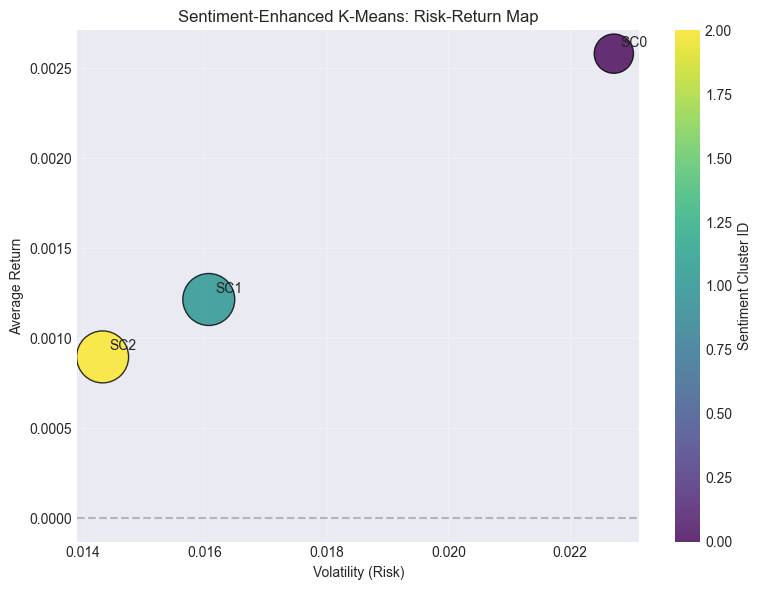

[OK] Saved: 11_sentiment_kmeans_risk_return_map.png


In [7]:
stock_profile = reg_df.groupby('Name').agg(
    volatility=('daily_return', 'std'),
    avg_return=('daily_return', 'mean'),
    avg_volume=('volume', 'mean'),
    volume_volatility=('volume', 'std'),
    momentum=('momentum_20', 'mean'),
    price_range=('price_range', 'mean'),
    trend_strength=('close_open_diff', 'mean'),
    price_level=('close', 'mean'),
    volume_to_price_ratio=('volume_norm', 'mean'),
    sentiment_mean=('sentiment_score', 'mean'),
    sentiment_std=('sentiment_score', 'std')
).fillna(0.0).reset_index()

cluster_features = [
    'volatility', 'avg_return', 'avg_volume', 'volume_volatility', 'momentum',
    'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio',
    'sentiment_mean', 'sentiment_std'
]

scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(stock_profile[cluster_features])

kmeans_sent = KMeans(n_clusters=3, random_state=42, n_init=20)
stock_profile['sent_cluster'] = kmeans_sent.fit_predict(X_km)

km_out = DATA_DIR / '02C_sentiment_kmeans_stock_assignments.csv'
stock_profile.to_csv(km_out, index=False)
print(f'[OK] Saved: {km_out.name}')

# Risk-return finance view for sentiment-enhanced clusters
finance_view = stock_profile.groupby('sent_cluster').agg(
    avg_return=('avg_return', 'mean'),
    volatility=('volatility', 'mean'),
    sentiment_mean=('sentiment_mean', 'mean'),
    n_stocks=('Name', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
size = (finance_view['n_stocks'] / finance_view['n_stocks'].max()) * 1200 + 200
sc = ax.scatter(finance_view['volatility'], finance_view['avg_return'], s=size, c=finance_view['sent_cluster'], cmap='viridis', alpha=0.8, edgecolors='black')
for _, r in finance_view.iterrows():
    ax.annotate(f"SC{int(r['sent_cluster'])}", (r['volatility'], r['avg_return']), xytext=(5, 5), textcoords='offset points')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Sentiment-Enhanced K-Means: Risk-Return Map')
ax.set_xlabel('Volatility (Risk)')
ax.set_ylabel('Average Return')
ax.grid(alpha=0.3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Sentiment Cluster ID')
plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '11_sentiment_kmeans_risk_return_map.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Saved: 11_sentiment_kmeans_risk_return_map.png')

## Step 5: Sentiment-Enhanced Regression Comparison

Compare baseline regression vs sentiment-enhanced regression.

,MAE,RMSE,MAPE(%),R2
Baseline (No Sentiment),4.968022,9.517169,1.080820,0.999519
Sentiment-Enhanced (Lag+Decay),4.848430,9.304999,1.063729,0.999541


MAE improvement from lag+decay sentiment: 2.41%
Train period end: 2017-03-13 00:00:00 | Test period start: 2017-03-14 00:00:00


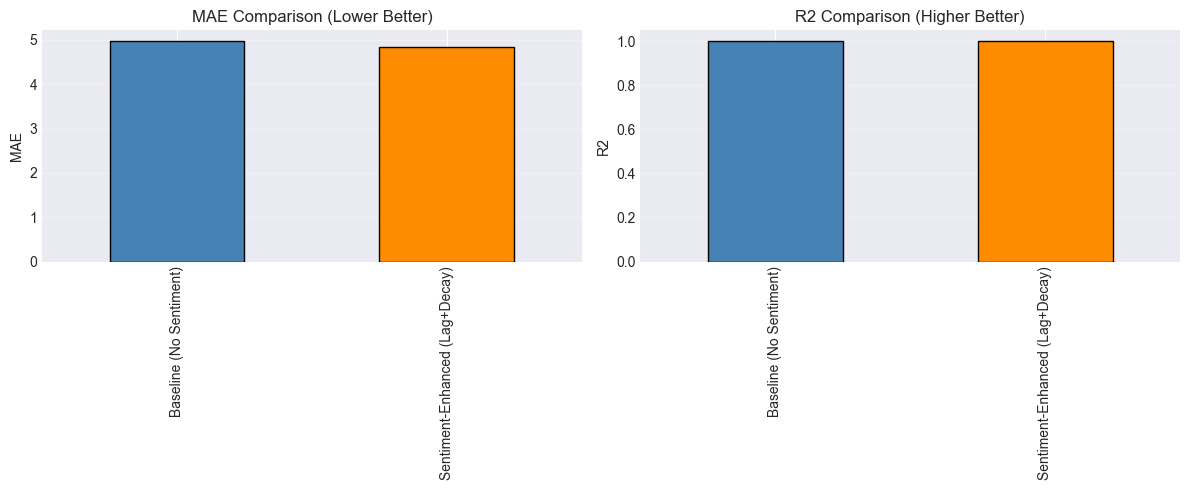

[OK] Saved: 12_sentiment_regression_comparison.png


In [8]:
base_features = [
    'price_range', 'close_open_diff', 'high_low_ratio', 'daily_return', 'lag_return_1', 'lag_return_5',
    'volume_norm', 'volume_trend', 'close_ma5', 'close_ma20', 'close_ma50',
    'momentum_5', 'momentum_20', 'volatility_20', 'volatility_60', 'rsi'
]

# Feature optimization: lagging-only sentiment + recency decay weighting.
sent_features = base_features + [
    'sentiment_lag1', 'sentiment_lag2', 'sentiment_lag3',
    'sentiment_lag3_mean', 'sentiment_lag5_mean',
    'sentiment_decay_10d', 'headline_decay_10d', 'sentiment_10d_std'
]

reg_df = reg_df.sort_values(['date', 'Name']).reset_index(drop=True)
split_date = reg_df['date'].quantile(0.8)
train_df = reg_df[reg_df['date'] <= split_date].copy()
test_df = reg_df[reg_df['date'] > split_date].copy()

X_train_base = train_df[base_features].fillna(0.0).values
X_test_base = test_df[base_features].fillna(0.0).values
X_train_sent = train_df[sent_features].fillna(0.0).values
X_test_sent = test_df[sent_features].fillna(0.0).values

y_train = train_df['target_return'].values
y_test_return = test_df['target_return'].values
y_test_close = test_df['target'].values
base_close_test = test_df['close'].values

sc_base = StandardScaler()
X_train_base = sc_base.fit_transform(X_train_base)
X_test_base = sc_base.transform(X_test_base)

sc_sent = StandardScaler()
X_train_sent = sc_sent.fit_transform(X_train_sent)
X_test_sent = sc_sent.transform(X_test_sent)

model_base = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, objective='reg:squarederror', n_jobs=-1)
model_sent = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, objective='reg:squarederror', n_jobs=-1)

model_base.fit(X_train_base, y_train)
model_sent.fit(X_train_sent, y_train)

pred_base_return = np.clip(model_base.predict(X_test_base), -0.2, 0.2)
pred_sent_return = np.clip(model_sent.predict(X_test_sent), -0.2, 0.2)

# Convert predicted return back to next-day close price for evaluation/plotting.
pred_base = base_close_test * (1 + pred_base_return)
pred_sent = base_close_test * (1 + pred_sent_return)

def eval_metrics(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAPE(%)': float(mean_absolute_percentage_error(y_true, y_pred) * 100),
        'R2': float(r2_score(y_true, y_pred))
    }

result_df = pd.DataFrame({
    'Baseline (No Sentiment)': eval_metrics(y_test_close, pred_base),
    'Sentiment-Enhanced (Lag+Decay)': eval_metrics(y_test_close, pred_sent)
}).T

display(result_df)

improve_mae = (result_df.loc['Baseline (No Sentiment)', 'MAE'] - result_df.loc['Sentiment-Enhanced (Lag+Decay)', 'MAE']) / result_df.loc['Baseline (No Sentiment)', 'MAE'] * 100
print(f'MAE improvement from lag+decay sentiment: {improve_mae:.2f}%')
print(f'Train period end: {train_df["date"].max()} | Test period start: {test_df["date"].min()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
result_df['MAE'].plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'], edgecolor='black')
axes[0].set_title('MAE Comparison (Lower Better)')
axes[0].set_ylabel('MAE')
axes[0].grid(axis='y', alpha=0.3)

result_df['R2'].plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'], edgecolor='black')
axes[1].set_title('R2 Comparison (Higher Better)')
axes[1].set_ylabel('R2')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '12_sentiment_regression_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Saved: 12_sentiment_regression_comparison.png')

,lookback_days,decay_rate,MAE,RMSE,MAPE(%),R2
0,5,0.10,4.84843,9.304999,1.063729,0.999541
1,5,0.20,4.84843,9.304999,1.063729,0.999541
2,5,0.25,4.84843,9.304999,1.063729,0.999541
3,5,0.35,4.84843,9.304999,1.063729,0.999541
4,5,0.50,4.84843,9.304999,1.063729,0.999541
5,10,0.10,4.84843,9.304999,1.063729,0.999541
6,10,0.20,4.84843,9.304999,1.063729,0.999541
7,10,0.25,4.84843,9.304999,1.063729,0.999541
8,10,0.35,4.84843,9.304999,1.063729,0.999541
9,10,0.50,4.84843,9.304999,1.063729,0.999541


[AUTO-TUNE] Best lookback_days=5, decay_rate=0.10, MAE=4.848430


,MAE,RMSE,MAPE(%),R2
Baseline (No Sentiment),4.968022,9.517169,1.080820,0.999519
Sentiment-Enhanced (Auto-Tuned Lag+Decay),4.848430,9.304999,1.063729,0.999541


[OK] Saved: 02C_lag_decay_grid_search.csv


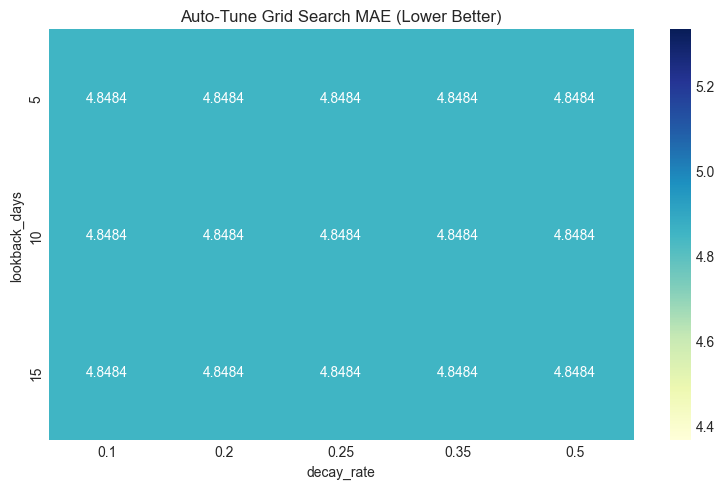

[OK] Saved: 15_lag_decay_grid_search_mae_heatmap.png


In [ ]:
# Auto-tuning lag window + decay rate (updates sent_features and predictions for downstream cells)
lookback_grid = [5, 10, 15]
decay_grid = [0.10, 0.20, 0.25, 0.35, 0.50]

# Keep a clean base frame, then re-generate lag/decay features each trial.
reg_tune_base = reg_df.copy()

candidate_sent_features = [
    'sentiment_lag1', 'sentiment_lag2', 'sentiment_lag3',
    'sentiment_lag3_mean', 'sentiment_lag5_mean',
    'sentiment_decay_10d', 'headline_decay_10d', 'sentiment_10d_std'
]

def evaluate_lag_decay_combo(df_base, lookback_days, decay_rate):
    df_c = add_sentiment_lag_decay_features(df_base.copy(), lookback_days=lookback_days, decay_rate=decay_rate)
    df_c = df_c.sort_values(['date', 'Name']).reset_index(drop=True)

    split_local = df_c['date'].quantile(0.8)
    tr = df_c[df_c['date'] <= split_local].copy()
    te = df_c[df_c['date'] > split_local].copy()

    feats = base_features + candidate_sent_features

    X_tr = tr[feats].fillna(0.0).values
    X_te = te[feats].fillna(0.0).values
    y_tr = tr['target_return'].values
    y_te_close = te['target'].values
    close_te = te['close'].values

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    model = XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, random_state=42,
        objective='reg:squarederror', n_jobs=-1
    )
    model.fit(X_tr, y_tr)

    pred_ret = np.clip(model.predict(X_te), -0.2, 0.2)
    pred_close = close_te * (1 + pred_ret)

    sent_block = te[candidate_sent_features].fillna(0.0)
    sent_abs_mean = float(sent_block.abs().mean().mean())
    sent_nonzero_ratio = float((sent_block.abs() > 1e-12).mean().mean())

    return {
        'lookback_days': int(lookback_days),
        'decay_rate': float(decay_rate),
        'MAE': float(mean_absolute_error(y_te_close, pred_close)),
        'RMSE': float(np.sqrt(mean_squared_error(y_te_close, pred_close))),
        'MAPE(%)': float(mean_absolute_percentage_error(y_te_close, pred_close) * 100),
        'R2': float(r2_score(y_te_close, pred_close)),
        'sent_abs_mean': sent_abs_mean,
        'sent_nonzero_ratio': sent_nonzero_ratio
    }

# Grid search
rows = []
for lb in lookback_grid:
    for dr in decay_grid:
        rows.append(evaluate_lag_decay_combo(reg_tune_base, lookback_days=lb, decay_rate=dr))

search_df = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
display(search_df)

mae_nunique = int(search_df['MAE'].round(10).nunique())
print(f'[AUTO-TUNE] Unique MAE values: {mae_nunique}')
if mae_nunique == 1:
    print('[WARN] All MAE values are identical across grid. Sentiment features may be low-signal or mostly constant in this split.')
    print(f"[WARN] Mean sent_abs_mean={search_df['sent_abs_mean'].mean():.6f}, mean sent_nonzero_ratio={search_df['sent_nonzero_ratio'].mean():.6f}")

best_cfg = search_df.iloc[0]
best_lookback = int(best_cfg['lookback_days'])
best_decay = float(best_cfg['decay_rate'])

print(f'[AUTO-TUNE] Best lookback_days={best_lookback}, decay_rate={best_decay:.2f}, MAE={best_cfg["MAE"]:.6f}')

# Apply best config to working dataset and re-train main Step 5 models for downstream usage.
reg_df = add_sentiment_lag_decay_features(reg_tune_base.copy(), lookback_days=best_lookback, decay_rate=best_decay)
sent_features = base_features + candidate_sent_features

reg_df = reg_df.sort_values(['date', 'Name']).reset_index(drop=True)
split_date = reg_df['date'].quantile(0.8)
train_df = reg_df[reg_df['date'] <= split_date].copy()
test_df = reg_df[reg_df['date'] > split_date].copy()

X_train_base = train_df[base_features].fillna(0.0).values
X_test_base = test_df[base_features].fillna(0.0).values
X_train_sent = train_df[sent_features].fillna(0.0).values
X_test_sent = test_df[sent_features].fillna(0.0).values

y_train = train_df['target_return'].values
y_test_close = test_df['target'].values
base_close_test = test_df['close'].values

sc_base = StandardScaler()
X_train_base = sc_base.fit_transform(X_train_base)
X_test_base = sc_base.transform(X_test_base)

sc_sent = StandardScaler()
X_train_sent = sc_sent.fit_transform(X_train_sent)
X_test_sent = sc_sent.transform(X_test_sent)

model_base = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, objective='reg:squarederror', n_jobs=-1)
model_sent = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, objective='reg:squarederror', n_jobs=-1)

model_base.fit(X_train_base, y_train)
model_sent.fit(X_train_sent, y_train)

pred_base_return = np.clip(model_base.predict(X_test_base), -0.2, 0.2)
pred_sent_return = np.clip(model_sent.predict(X_test_sent), -0.2, 0.2)
pred_base = base_close_test * (1 + pred_base_return)
pred_sent = base_close_test * (1 + pred_sent_return)

result_tuned_df = pd.DataFrame({
    'Baseline (No Sentiment)': eval_metrics(y_test_close, pred_base),
    'Sentiment-Enhanced (Auto-Tuned Lag+Decay)': eval_metrics(y_test_close, pred_sent)
}).T

display(result_tuned_df)

# Save search results and a heatmap for fast review
search_out = DATA_DIR / '02C_lag_decay_grid_search.csv'
search_df.to_csv(search_out, index=False)
print(f'[OK] Saved: {search_out.name}')

pivot_mae = search_df.pivot(index='lookback_days', columns='decay_rate', values='MAE')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_mae, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax)
ax.set_title('Auto-Tune Grid Search MAE (Lower Better)')
ax.set_xlabel('decay_rate')
ax.set_ylabel('lookback_days')
plt.tight_layout()

heatmap_out = GRAPH_DIR / '15_lag_decay_grid_search_mae_heatmap.png'
plt.savefig(str(heatmap_out), dpi=300, bbox_inches='tight')
plt.show()
print(f'[OK] Saved: {heatmap_out.name}')

## Step 5A: Auto-Tuning for Lagging Sentiment Features

Grid search on:
- `lookback_days` (lag window length)
- `decay_rate` (recency decay speed)

Objective: minimize test MAE for sentiment-enhanced model under strict lagging setup.

In [10]:
# 02C cluster-specific regression (aligned with 02B style)
MIN_CLUSTER_SAMPLES_02C = 50
CLIP_RET = 0.2

cluster_model_params = dict(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

def train_predict_cluster_models(train_src, pred_src, feature_cols, target_col='target_return', cluster_col='cluster', min_samples=50, model_params=None):
    if model_params is None:
        model_params = cluster_model_params

    pred_ret = np.full(len(pred_src), np.nan, dtype=float)
    model_meta = []

    cluster_ids_local = sorted(train_src[cluster_col].dropna().astype(int).unique().tolist())
    for cid in cluster_ids_local:
        tr = train_src[train_src[cluster_col] == cid]
        te = pred_src[pred_src[cluster_col] == cid]

        if len(tr) < min_samples:
            continue

        X_tr = tr[feature_cols].fillna(0.0).values
        y_tr = tr[target_col].values

        scaler_c = StandardScaler()
        X_tr = scaler_c.fit_transform(X_tr)

        model_c = XGBRegressor(**model_params)
        model_c.fit(X_tr, y_tr)

        if len(te) > 0:
            X_te = te[feature_cols].fillna(0.0).values
            X_te = scaler_c.transform(X_te)
            pred_c = model_c.predict(X_te)
            te_pos = pred_src.index.get_indexer(te.index)
            pred_ret[te_pos] = pred_c

        model_meta.append({'cluster': int(cid), 'train_rows': int(len(tr)), 'pred_rows': int(len(te))})

    return pred_ret, pd.DataFrame(model_meta)

# Strict in-train temporal split for blend alpha tuning
val_cutoff = train_df['date'].quantile(0.85)
train_core_df = train_df[train_df['date'] <= val_cutoff].copy()
val_df = train_df[train_df['date'] > val_cutoff].copy()

if len(val_df) < 50:
    split_idx = int(len(train_df) * 0.85)
    train_core_df = train_df.iloc[:split_idx].copy()
    val_df = train_df.iloc[split_idx:].copy()

# Global sentiment model on core train
X_train_core = train_core_df[sent_features].fillna(0.0).values
X_val = val_df[sent_features].fillna(0.0).values
y_train_core = train_core_df['target_return'].values

sc_core = StandardScaler()
X_train_core = sc_core.fit_transform(X_train_core)
X_val = sc_core.transform(X_val)

global_core = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=42,
    objective='reg:squarederror', n_jobs=-1
)
global_core.fit(X_train_core, y_train_core)
pred_global_val_ret = global_core.predict(X_val)

# Cluster-specific sentiment model for validation
pred_cluster_val_ret, cluster_val_meta = train_predict_cluster_models(
    train_core_df,
    val_df,
    sent_features,
    target_col='target_return',
    cluster_col='cluster',
    min_samples=MIN_CLUSTER_SAMPLES_02C,
    model_params=cluster_model_params
)

missing_val = np.isnan(pred_cluster_val_ret)
pred_cluster_val_ret[missing_val] = pred_global_val_ret[missing_val]

val_base_close = val_df['close'].values
y_val_close = val_df['target'].values
pred_global_val_close = val_base_close * (1 + np.clip(pred_global_val_ret, -CLIP_RET, CLIP_RET))
pred_cluster_val_close = val_base_close * (1 + np.clip(pred_cluster_val_ret, -CLIP_RET, CLIP_RET))

alpha_grid = np.linspace(0.0, 1.0, 21)
best_alpha_02c = 0.5
best_val_mae_02c = float('inf')

for a in alpha_grid:
    pred_blend_val_close = a * pred_global_val_close + (1.0 - a) * pred_cluster_val_close
    mae_val = float(mean_absolute_error(y_val_close, pred_blend_val_close))
    if mae_val < best_val_mae_02c:
        best_val_mae_02c = mae_val
        best_alpha_02c = float(a)

# Final cluster-specific sentiment model on full train -> test
pred_cluster_test_ret, cluster_test_meta = train_predict_cluster_models(
    train_df,
    test_df,
    sent_features,
    target_col='target_return',
    cluster_col='cluster',
    min_samples=MIN_CLUSTER_SAMPLES_02C,
    model_params=cluster_model_params
)

missing_test = np.isnan(pred_cluster_test_ret)
pred_cluster_test_ret[missing_test] = pred_sent_return[missing_test]

pred_cluster_02c = base_close_test * (1 + np.clip(pred_cluster_test_ret, -CLIP_RET, CLIP_RET))
pred_blend_02c_ret = best_alpha_02c * pred_sent_return + (1.0 - best_alpha_02c) * pred_cluster_test_ret
pred_blend_02c = base_close_test * (1 + np.clip(pred_blend_02c_ret, -CLIP_RET, CLIP_RET))

result_02c_cluster_df = pd.DataFrame({
    '02C Global Sentiment': eval_metrics(y_test_close, pred_sent),
    '02C Cluster-Specific Sentiment': eval_metrics(y_test_close, pred_cluster_02c),
    '02C Blended (Global+Cluster)': eval_metrics(y_test_close, pred_blend_02c)
}).T

display(result_02c_cluster_df)

print(f'[02C] Tuned blend alpha: {best_alpha_02c:.2f} (validation MAE: {best_val_mae_02c:.4f})')
print(f'[02C] Cluster experts trained: {len(cluster_test_meta)} / {reg_df["cluster"].nunique()}')
if len(cluster_test_meta) > 0:
    display(cluster_test_meta.sort_values('cluster').reset_index(drop=True))

out_02c_cluster_metrics = DATA_DIR / '02C_cluster_specific_regression_comparison.csv'
result_02c_cluster_df.to_csv(out_02c_cluster_metrics, index=True)
print(f'[OK] Saved: {out_02c_cluster_metrics.name}')

# 5-stock per-stock metrics (same spec mindset as 02B)
requested_stocks_eval = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
stock_perf_02c = []

for stock in requested_stocks_eval:
    g = test_df[test_df['Name'] == stock]
    if len(g) == 0:
        continue

    pos = test_df.index.get_indexer(g.index)
    y_true = g['target'].values

    y_global = pred_sent[pos]
    y_cluster = pred_cluster_02c[pos]
    y_blend = pred_blend_02c[pos]

    stock_perf_02c.append({
        'Stock': stock,
        'Test_Samples': int(len(g)),
        '02C_GlobalSent_MAE': float(mean_absolute_error(y_true, y_global)),
        '02C_GlobalSent_R2': float(r2_score(y_true, y_global)),
        '02C_ClusterSpecific_MAE': float(mean_absolute_error(y_true, y_cluster)),
        '02C_ClusterSpecific_R2': float(r2_score(y_true, y_cluster)),
        '02C_Blended_MAE': float(mean_absolute_error(y_true, y_blend)),
        '02C_Blended_R2': float(r2_score(y_true, y_blend))
    })

stock_perf_02c_df = pd.DataFrame(stock_perf_02c)
display(stock_perf_02c_df)
out_stock_02c = DATA_DIR / '02C_stock_level_regression_performance.csv'
stock_perf_02c_df.to_csv(out_stock_02c, index=False)
print(f'[OK] Saved: {out_stock_02c.name}')

,MAE,RMSE,MAPE(%),R2
02C Global Sentiment,4.848430,9.304999,1.063729,0.999541
02C Cluster-Specific Sentiment,5.092636,9.492639,1.262490,0.999522
02C Blended (Global+Cluster),4.848430,9.304999,1.063729,0.999541


[02C] Tuned blend alpha: 1.00 (validation MAE: 3.8124)
[02C] Cluster experts trained: 3 / 3


,cluster,train_rows,pred_rows
0,0,970,228
1,1,1940,456
2,5,1656,456


[OK] Saved: 02C_cluster_specific_regression_comparison.csv


,Stock,Test_Samples,02C_GlobalSent_MAE,02C_GlobalSent_R2,02C_ClusterSpecific_MAE,02C_ClusterSpecific_R2,02C_Blended_MAE,02C_Blended_R2
0,AAPL,228,1.460178,0.966893,1.553391,0.963175,1.460178,0.966893
1,MSFT,228,0.593894,0.987213,0.749776,0.982629,0.593894,0.987213
2,GOOG,228,8.120661,0.979811,8.067140,0.978966,8.120663,0.979811
3,AMZN,228,11.147500,0.985375,10.794006,0.985440,11.147500,0.985375
4,NVDA,228,2.919915,0.988583,4.298868,0.980655,2.919914,0.988583


[OK] Saved: 02C_stock_level_regression_performance.csv


02B vs 02C (5-stock MAE, lower is better):


,Stock,02B_Blended_MAE,02C_GlobalSent_MAE,02C_ClusterSpecific_MAE,02C_Blended_MAE,Best_Model
0,AAPL,1.670681,1.460178,1.553391,1.460178,02C_GlobalSent_MAE
1,AMZN,15.105198,11.147500,10.794006,11.147500,02C_ClusterSpecific_MAE
2,GOOG,15.046579,8.120661,8.067140,8.120663,02C_ClusterSpecific_MAE
3,MSFT,0.617315,0.593894,0.749776,0.593894,02C_Blended_MAE
4,NVDA,3.274333,2.919915,4.298868,2.919914,02C_Blended_MAE


[OK] Saved: 02BC_5stock_same_spec_comparison.csv


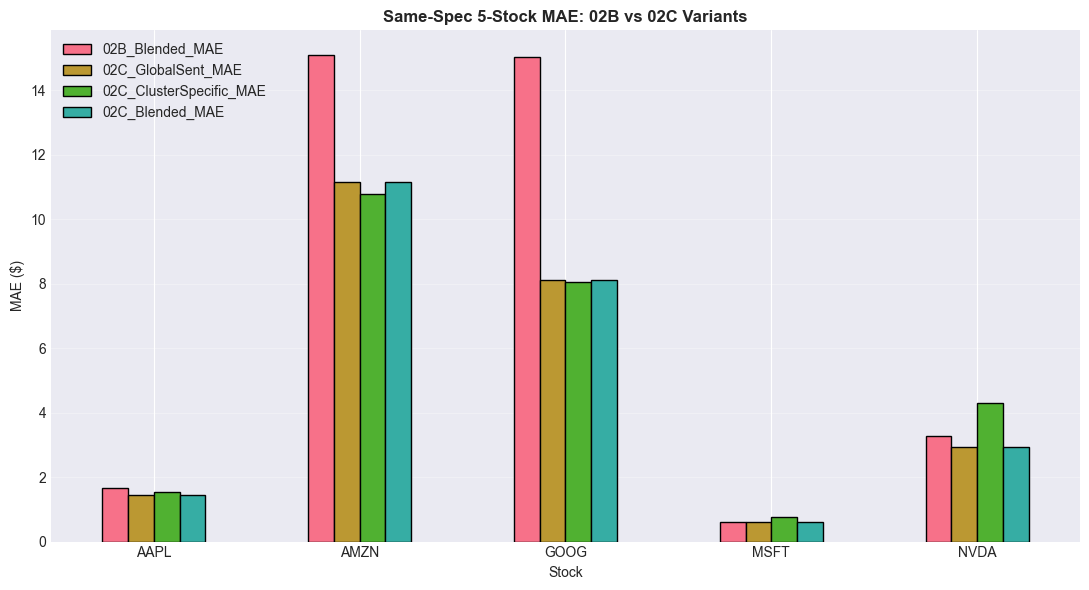

[OK] Saved: 14_02BC_5stock_same_spec_mae_comparison.png


In [11]:
# Compare 02C (new cluster-specific variants) with 02B on the same 5 stocks
path_02b_stock = DATA_DIR / '02B_stock_level_regression_performance.csv'

if not path_02b_stock.exists():
    print(f'[WARN] Missing 02B stock-level file: {path_02b_stock.name}')
    print('Please run 02B notebook per-stock section first.')
else:
    perf_02b = pd.read_csv(path_02b_stock)
    perf_02c = stock_perf_02c_df.copy()

    compare_5_df = perf_02b[['Stock', 'Blended_MAE']].rename(columns={'Blended_MAE': '02B_Blended_MAE'})
    compare_5_df = compare_5_df.merge(
        perf_02c[['Stock', '02C_GlobalSent_MAE', '02C_ClusterSpecific_MAE', '02C_Blended_MAE']],
        on='Stock',
        how='inner'
    )

    for c in ['02B_Blended_MAE', '02C_GlobalSent_MAE', '02C_ClusterSpecific_MAE', '02C_Blended_MAE']:
        compare_5_df[c] = compare_5_df[c].astype(float)

    compare_5_df['Best_Model'] = compare_5_df[
        ['02B_Blended_MAE', '02C_GlobalSent_MAE', '02C_ClusterSpecific_MAE', '02C_Blended_MAE']
    ].idxmin(axis=1)
    compare_5_df = compare_5_df.sort_values('Stock').reset_index(drop=True)

    print('02B vs 02C (5-stock MAE, lower is better):')
    display(compare_5_df)

    out_compare = DATA_DIR / '02BC_5stock_same_spec_comparison.csv'
    compare_5_df.to_csv(out_compare, index=False)
    print(f'[OK] Saved: {out_compare.name}')

    # Visualization
    vis_cols = ['02B_Blended_MAE', '02C_GlobalSent_MAE', '02C_ClusterSpecific_MAE', '02C_Blended_MAE']
    plot_cmp = compare_5_df.set_index('Stock')[vis_cols]

    fig, ax = plt.subplots(figsize=(11, 6))
    plot_cmp.plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title('Same-Spec 5-Stock MAE: 02B vs 02C Variants', fontsize=12, fontweight='bold')
    ax.set_ylabel('MAE ($)')
    ax.set_xlabel('Stock')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(loc='upper left')
    plt.tight_layout()

    out_cmp_plot = GRAPH_DIR / '14_02BC_5stock_same_spec_mae_comparison.png'
    plt.savefig(str(out_cmp_plot), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'[OK] Saved: {out_cmp_plot.name}')

## Step 5B: 02C Cluster-Specific Regression (Same Spec as 02B)

Add per-cluster expert models on top of sentiment features, then compare:
- 02C Global Sentiment model
- 02C Cluster-Specific Sentiment model
- 02C Blended (Global + Cluster) model

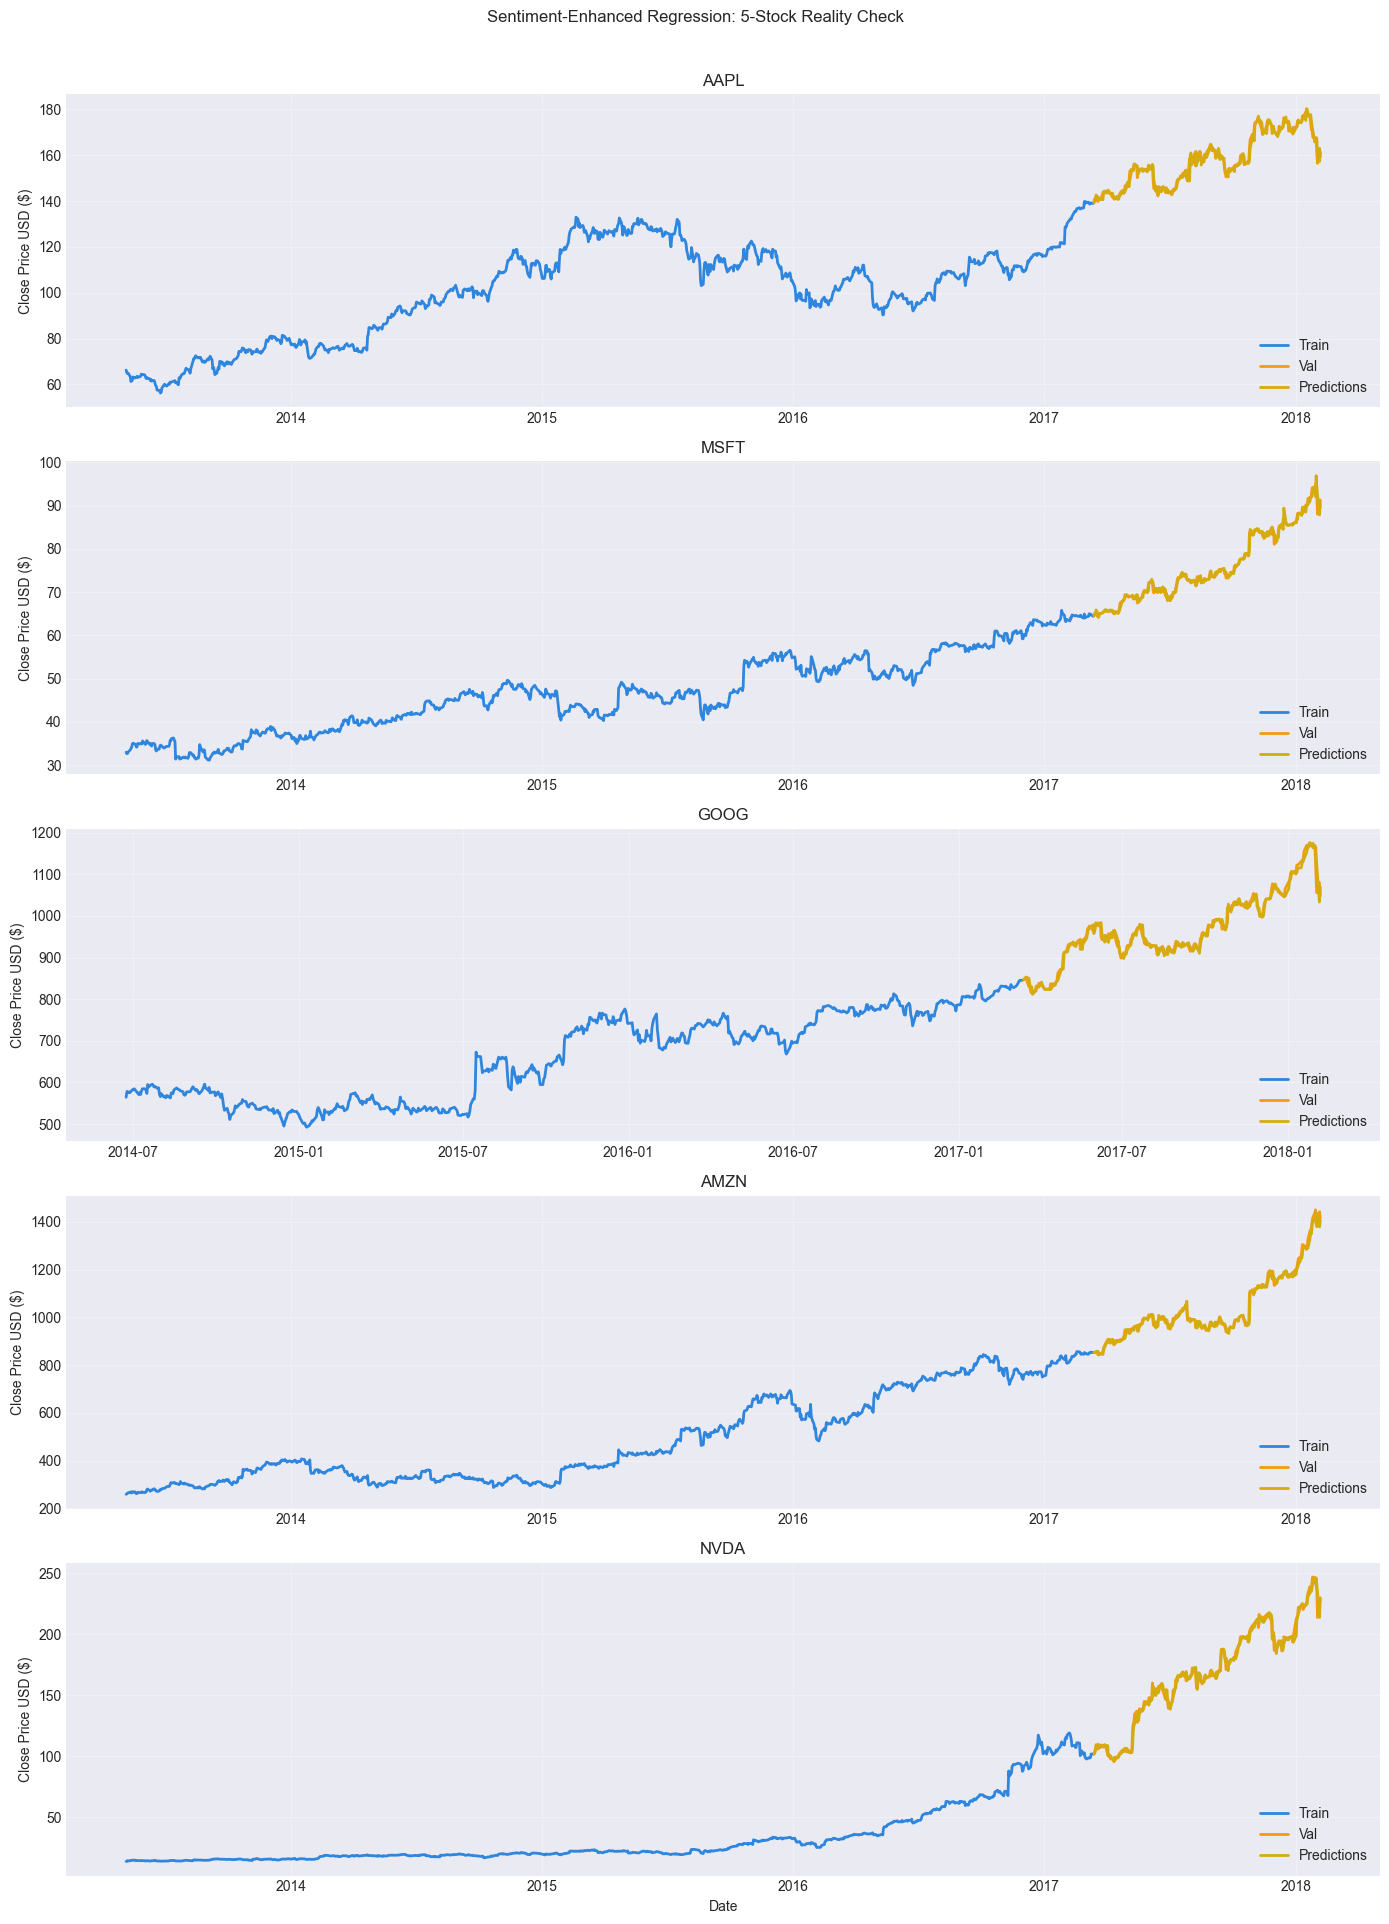

[OK] Saved: 13_sentiment_prediction_vs_actual_requested5.png
Plotted requested stocks: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']


In [12]:
# Step 6: Reality check for 5 requested stocks (Train / Val / Predictions)
requested_stocks = ["AAPL", "MSFT", "GOOG", "AMZN", "NVDA"]

plot_df = test_df[['date', 'Name', 'target']].copy()
plot_df['pred_sent'] = pred_sent

fig, axes = plt.subplots(len(requested_stocks), 1, figsize=(14, 3.8 * len(requested_stocks)), sharex=False)
if len(requested_stocks) == 1:
    axes = [axes]

plotted = []
missing = []

for ax, stock in zip(axes, requested_stocks):
    stock_train = train_df[train_df['Name'] == stock].sort_values('date')
    stock_val = plot_df[plot_df['Name'] == stock].sort_values('date')

    if stock_train.empty and stock_val.empty:
        ax.text(0.5, 0.5, f'No data for {stock}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{stock} (No Data)')
        ax.grid(alpha=0.3)
        missing.append(stock)
        continue

    if not stock_train.empty:
        ax.plot(stock_train['date'], stock_train['target'], label='Train', color='#2E86DE', linewidth=2)
    if not stock_val.empty:
        ax.plot(stock_val['date'], stock_val['target'], label='Val', color='#F39C12', linewidth=2)
        ax.plot(stock_val['date'], stock_val['pred_sent'], label='Predictions', color='#D4AC0D', linewidth=2)

    ax.set_title(stock)
    ax.set_ylabel('Close Price USD ($)')
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right')
    plotted.append(stock)

axes[-1].set_xlabel('Date')
fig.suptitle('Sentiment-Enhanced Regression: 5-Stock Reality Check', y=1.01)
plt.tight_layout()

out_path = GRAPH_DIR / '13_sentiment_prediction_vs_actual_requested5.png'
plt.savefig(str(out_path), dpi=300, bbox_inches='tight')
plt.show()

print(f'[OK] Saved: {out_path.name}')
print(f'Plotted requested stocks: {plotted}')
if missing:
    print(f'Missing requested stocks (no train and val rows): {missing}')

## Summary
- Added sentiment extraction pipeline from shared raw news data
- Integrated sentiment into K-Means (cluster profiling)
- Integrated sentiment into regression and compared metrics

If you need to refresh the shared raw news cache, run `project_folder/news_data/implementation/01_News_Data_Ingestion.ipynb` first.

## Final Results

This section consolidates the final tuned configuration, overall metrics, cluster-specific metrics, and the 5-stock comparison against 02B.

In [16]:
# Compact narrative summary for quick review
print('\n' + '=' * 90)
print('02C FINAL SUMMARY')
print('=' * 90)
print(f"Auto-tuned lag/decay: lookback_days={best_lookback}, decay_rate={best_decay:.2f}, MAE={best_cfg['MAE']:.6f}")
print(f"Overall baseline MAE: {result_tuned_df.loc['Baseline (No Sentiment)', 'MAE']:.6f}")
print(f"Overall tuned sentiment MAE: {result_tuned_df.loc['Sentiment-Enhanced (Auto-Tuned Lag+Decay)', 'MAE']:.6f}")
print(f"Overall MAE improvement: {(result_tuned_df.loc['Baseline (No Sentiment)', 'MAE'] - result_tuned_df.loc['Sentiment-Enhanced (Auto-Tuned Lag+Decay)', 'MAE']) / result_tuned_df.loc['Baseline (No Sentiment)', 'MAE'] * 100:.2f}%")
print(f"Best alpha for cluster blending: {best_alpha_02c:.2f}")

if 'compare_5_df' in globals() and len(compare_5_df) > 0 and 'Best_Model' in compare_5_df.columns:
    best_count_df = compare_5_df['Best_Model'].value_counts().rename_axis('Model').reset_index(name='Wins')
else:
    best_count_df = pd.DataFrame(columns=['Model', 'Wins'])
print('\n5-stock best model counts:')
print(best_count_df.to_string(index=False))
print('\nOutput files saved in data/ and graph/ folders.')


02C FINAL SUMMARY
Auto-tuned lag/decay: lookback_days=5, decay_rate=0.10, MAE=4.848430
Overall baseline MAE: 4.968022
Overall tuned sentiment MAE: 4.848430
Overall MAE improvement: 2.41%
Best alpha for cluster blending: 1.00

5-stock best model counts:
                  Model  Wins
02C_ClusterSpecific_MAE     2
        02C_Blended_MAE     2
     02C_GlobalSent_MAE     1

Output files saved in data/ and graph/ folders.


In [ ]:
# Final consolidated summary
final_summary_rows = []

# Auto-tune summary
final_summary_rows.append({
    'Section': 'Auto-Tuned Lag+Decay',
    'Item': 'Best lookback_days',
    'Value': int(best_lookback)
})
final_summary_rows.append({
    'Section': 'Auto-Tuned Lag+Decay',
    'Item': 'Best decay_rate',
    'Value': float(best_decay)
})
final_summary_rows.append({
    'Section': 'Auto-Tuned Lag+Decay',
    'Item': 'Grid-search MAE',
    'Value': float(best_cfg['MAE'])
})
final_summary_rows.append({
    'Section': 'Auto-Tuned Lag+Decay',
    'Item': 'Used by all news-based models',
    'Value': f'yes (lookback_days={best_lookback}, decay_rate={best_decay:.2f})'
})

# Overall model summary
for metric_name in ['MAE', 'RMSE', 'MAPE(%)', 'R2']:
    final_summary_rows.append({
        'Section': '02C Overall',
        'Item': f'Sentiment-Enhanced ({metric_name})',
        'Value': float(result_tuned_df.loc['Sentiment-Enhanced (Auto-Tuned Lag+Decay)', metric_name])
    })
    final_summary_rows.append({
        'Section': '02C Overall',
        'Item': f'Baseline ({metric_name})',
        'Value': float(result_tuned_df.loc['Baseline (No Sentiment)', metric_name])
    })

# Cluster-specific summary
for metric_name in ['MAE', 'RMSE', 'MAPE(%)', 'R2']:
    final_summary_rows.append({
        'Section': '02C Cluster-Specific',
        'Item': f'Global Sentiment ({metric_name})',
        'Value': float(result_02c_cluster_df.loc['02C Global Sentiment', metric_name])
    })
    final_summary_rows.append({
        'Section': '02C Cluster-Specific',
        'Item': f'Cluster-Specific ({metric_name})',
        'Value': float(result_02c_cluster_df.loc['02C Cluster-Specific Sentiment', metric_name])
    })
    final_summary_rows.append({
        'Section': '02C Cluster-Specific',
        'Item': f'Blended ({metric_name})',
        'Value': float(result_02c_cluster_df.loc['02C Blended (Global+Cluster)', metric_name])
    })

final_summary_df = pd.DataFrame(final_summary_rows)
display(final_summary_df)

print('\nFinal 5-stock comparison (02B vs 02C variants):')
display(compare_5_df)

# Aggregate model ranking across the 5 requested stocks
model_ranking_rows = []
model_specs = [
    {
        'name': '02B_Blended',
        'mae_col': 'Blended_MAE',
        'r2_col': 'Blended_R2',
        'source': perf_02b,
    },
    {
        'name': '02C_GlobalSent',
        'mae_col': '02C_GlobalSent_MAE',
        'r2_col': '02C_GlobalSent_R2',
        'source': perf_02c,
    },
    {
        'name': '02C_ClusterSpecific',
        'mae_col': '02C_ClusterSpecific_MAE',
        'r2_col': '02C_ClusterSpecific_R2',
        'source': perf_02c,
    },
    {
        'name': '02C_Blended',
        'mae_col': '02C_Blended_MAE',
        'r2_col': '02C_Blended_R2',
        'source': perf_02c,
    },
]

for spec in model_specs:
    model_ranking_rows.append({
        'Model': spec['name'],
        'Avg_MAE': float(spec['source'][spec['mae_col']].astype(float).mean()),
        'Avg_R2': float(spec['source'][spec['r2_col']].astype(float).mean()),
        'Stock_Wins': int((compare_5_df['Best_Model'] == (spec['mae_col'] if spec['name'] != '02B_Blended' else '02B_Blended_MAE')).sum())
    })

model_ranking_df = pd.DataFrame(model_ranking_rows).sort_values(['Avg_MAE', 'Avg_R2'], ascending=[True, False]).reset_index(drop=True)
model_ranking_df['Rank'] = np.arange(1, len(model_ranking_df) + 1)
model_ranking_df = model_ranking_df[['Rank', 'Model', 'Avg_MAE', 'Avg_R2', 'Stock_Wins']]

best_overall_model = model_ranking_df.iloc[0]
print('\nAggregate model ranking across the 5 requested stocks (lower Avg_MAE first, higher Avg_R2 tie-break):')
display(model_ranking_df)
print(f"Best overall model by Avg_MAE + Avg_R2: {best_overall_model['Model']}")

# Save consolidated outputs
final_summary_out = DATA_DIR / '02C_final_summary_table.csv'
final_summary_df.to_csv(final_summary_out, index=False)
model_ranking_out = DATA_DIR / '02C_model_ranking_5stock.csv'
model_ranking_df.to_csv(model_ranking_out, index=False)
print(f'[OK] Saved: {final_summary_out.name}')
print(f'[OK] Saved: {model_ranking_out.name}')

,Section,Item,Value
0,Auto-Tuned Lag+Decay,Best lookback_days,10
1,Auto-Tuned Lag+Decay,Best decay_rate,0.2
2,Auto-Tuned Lag+Decay,Grid-search MAE,4.838275
3,Auto-Tuned Lag+Decay,Used by all news-based models,"yes (lookback_days=10, decay_rate=0.20)"
4,02C Overall,Sentiment-Enhanced (MAE),4.838275
5,02C Overall,Baseline (MAE),4.968022
6,02C Overall,Sentiment-Enhanced (RMSE),9.297371
7,02C Overall,Baseline (RMSE),9.517169
8,02C Overall,Sentiment-Enhanced (MAPE(%)),1.069419
9,02C Overall,Baseline (MAPE(%)),1.08082



Final 5-stock comparison (02B vs 02C variants):


,Stock,02B_Blended_MAE,02C_GlobalSent_MAE,02C_ClusterSpecific_MAE,02C_Blended_MAE,Best_Model
0,AAPL,1.670681,1.417663,1.577958,1.417664,02C_GlobalSent_MAE
1,AMZN,15.105198,10.911145,10.616143,10.911143,02C_ClusterSpecific_MAE
2,GOOG,15.046579,8.266866,8.148287,8.266868,02C_ClusterSpecific_MAE
3,MSFT,0.617315,0.619027,0.710241,0.619027,02B_Blended_MAE
4,NVDA,3.274333,2.976671,4.480455,2.976671,02C_Blended_MAE



Aggregate model ranking across the 5 requested stocks (lower Avg_MAE first, higher Avg_R2 tie-break):


,Rank,Model,Avg_MAE,Avg_R2,Stock_Wins
0,1,02C_Blended,4.838274,0.981587,1
1,2,02C_GlobalSent,4.838275,0.981587,1
2,3,02C_ClusterSpecific,5.106617,0.978000,2
3,4,02B_Blended,7.142821,0.972249,1


Best overall model by Avg_MAE + Avg_R2: 02C_Blended
[OK] Saved: 02C_final_summary_table.csv
[OK] Saved: 02C_model_ranking_5stock.csv
